In [345]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")



In [346]:
df = pd.read_excel("swiggy_data.xlsx")

In [347]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


## DATA PREPROCESSING

In [348]:
print("Shape is :",df.shape)

Shape is : (197430, 10)


In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [350]:
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [351]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


## EDA

#### Hight Revienue by State

In [352]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [353]:
df.groupby("State")["Price (INR)"].sum().sort_values(ascending=False).head()

State
Karnataka        5456798.41
Uttar Pradesh    3117359.65
Telangana        3021711.62
Maharashtra      3015573.35
Delhi            2829180.60
Name: Price (INR), dtype: float64

 * Higest Revenue by state is karnataka
 * second is Uttar Pradesh
 * third is Telangana


In [354]:
import datetime as dt

In [355]:

df["Year"] = pd.to_datetime(df["Order Date"]).dt.year


In [356]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Year
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,2025
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,2025
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,2025
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,2025
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,2025


In [357]:
df.groupby("Year")["Price (INR)"].sum()

Year
2025    53012505.77
Name: Price (INR), dtype: float64

In [358]:
df["Month"] = df["Order Date"].dt.month_name()

df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Year,Month
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,2025,June
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,2025,April
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,2025,January
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,2025,April
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,2025,March


In [359]:
month_analysis =df.groupby("Month")["Price (INR)"].sum().reset_index()

In [360]:
month_analysis

,Month,Price (INR)
0,April,6594515.00
1,August,6791461.90
2,February,6269105.67
3,January,6825186.03
4,July,6650965.51
5,June,6514183.19
6,March,6573530.07
7,May,6793558.40


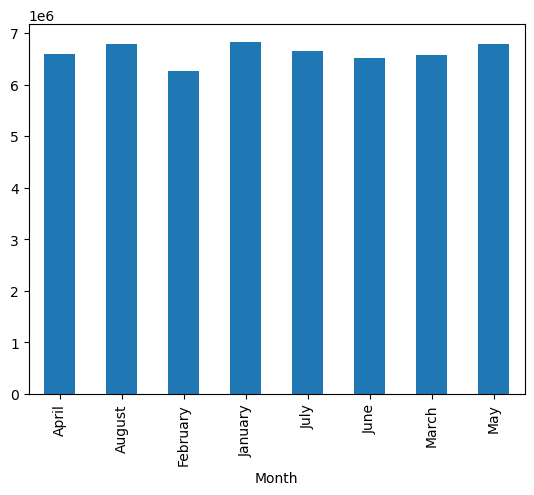

In [361]:
month_analysis =df.groupby("Month")["Price (INR)"].sum().plot(kind="bar")

### Restuarent wise Highest Sales

In [362]:
df.groupby("Restaurant Name")["Price (INR)"].sum().sort_values(ascending=False).head()

Restaurant Name
KFC               4246951.70
McDonald's        3343094.58
Pizza Hut         2133265.69
Burger King       1900817.09
Domino's Pizza    1834022.32
Name: Price (INR), dtype: float64

<Axes: xlabel='Restaurant Name'>

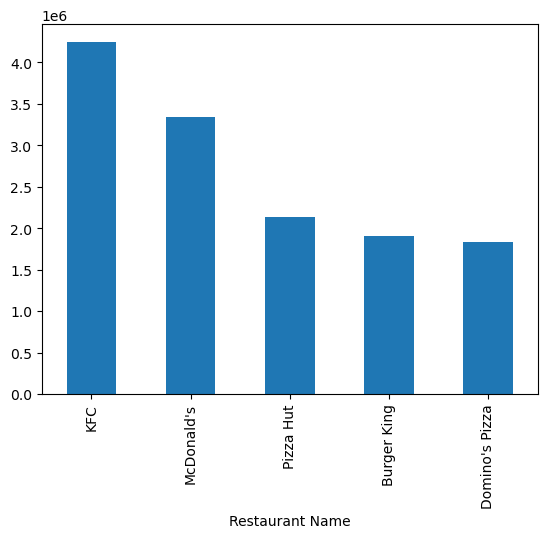

In [363]:
df.groupby("Restaurant Name")["Price (INR)"].sum().sort_values(ascending=False).head().plot(kind="bar")

* Total revenue gernerated based on the Resurents
* KFC has the highest revenue

### Average rating per restaurant

In [364]:
df.groupby("Restaurant Name")["Rating"].mean().sort_values(ascending=False)

Restaurant Name
Sakana                           4.815789
Vijay Dairy                      4.750000
Jagannath Mandir Arna Prasad     4.750000
Radhey Lal's Parampara Sweets    4.736905
I Deli Cafe                      4.736170
                                   ...   
Idly Dosa for You                3.785294
Roll Corner                      3.778409
Jai Krishna Vaishno Dhaba        3.742609
Dreams Cafe                      3.721212
Cafe 99                          3.685897
Name: Rating, Length: 993, dtype: float64

### Sales by food category (Snack, Recommended)

In [365]:
df.groupby("Category")["Price (INR)"].sum().sort_values(ascending=False)

Category
Recommended                     7188936.53
Main Course                      760045.00
Burger Combos ( 3 Pc Meals )     507773.55
McSaver Combos (2 Pc Meals)      431696.65
Desserts                         416311.28
                                   ...    
Bhaifota Special                     25.00
Water                                20.00
Add-ons                              16.95
Cool Drinks                          14.00
Bevarage                             10.00
Name: Price (INR), Length: 4972, dtype: float64

In [366]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count',
       'Year', 'Month'],
      dtype='object')

In [367]:
df["Restaurant Name"].value_counts(ascending=False).head()

Restaurant Name
McDonald's        13530
KFC               12961
Burger King        7116
Pizza Hut          6529
Domino's Pizza     5492
Name: count, dtype: int64

<Axes: xlabel='Restaurant Name'>

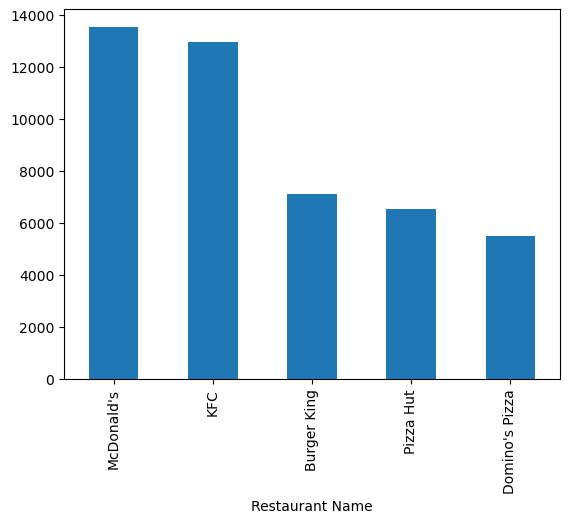

In [368]:
df["Restaurant Name"].value_counts(ascending=False).head().plot(kind="bar")

* Highest order Booking order was McDonald's
* Second is KFC

### Most ordered dishes

In [369]:
df["Dish Name"].value_counts(ascending=False).head().reset_index()

,Dish Name,count
0,Choco Lava Cake,303
1,Veg Fried Rice,243
2,Chicken Sausage,227
3,Paneer Butter Masala,226
4,Jeera Rice,219


<Axes: xlabel='Dish Name'>

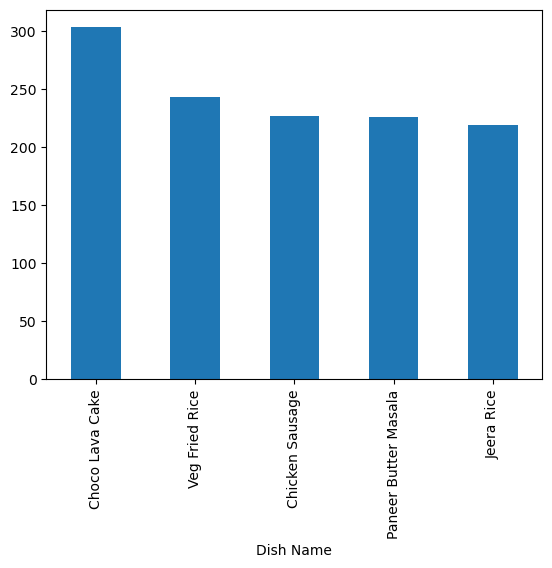

In [370]:
df["Dish Name"].value_counts(ascending=False).head().plot(kind="bar")

In [371]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Year,Month
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,2025,June
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,2025,April
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,2025,January
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,2025,April
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,2025,March


In [372]:
df["Day"] = df["Order Date"].dt.day

In [373]:
df1 =df

In [374]:
df1.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Year,Month,Day
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,2025,June,29
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,2025,April,3
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,2025,January,15
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,2025,April,17
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,2025,March,13


### Drop Columns NOT Useful for ML

In [375]:
df1.drop(columns=["Restaurant Name","Dish Name","Order Date"],inplace=True)

In [376]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   State         197430 non-null  object 
 1   City          197430 non-null  object 
 2   Location      197430 non-null  object 
 3   Category      197430 non-null  object 
 4   Price (INR)   197430 non-null  float64
 5   Rating        197430 non-null  float64
 6   Rating Count  197430 non-null  int64  
 7   Year          197430 non-null  int32  
 8   Month         197430 non-null  object 
 9   Day           197430 non-null  int32  
dtypes: float64(2), int32(2), int64(1), object(5)
memory usage: 13.6+ MB


In [377]:
df1

,State,City,Location,Category,Price (INR),Rating,Rating Count,Year,Month,Day
0,Karnataka,Bengaluru,Rajarajeshwari Nagar,Snack,133.9,4.0,0,2025,June,29
1,Karnataka,Bengaluru,Kengeri,Recommended,52.0,4.5,25,2025,April,3
2,Karnataka,Bengaluru,Kengeri,Recommended,117.0,4.7,48,2025,January,15
3,Karnataka,Bengaluru,Kengeri,Recommended,65.0,4.6,65,2025,April,17
4,Karnataka,Bengaluru,Kengeri,Recommended,130.0,4.0,0,2025,March,13
...,...,...,...,...,...,...,...,...,...,...
197425,Sikkim,Gangtok,Gangtok,Momos,112.0,4.4,0,2025,January,25
197426,Sikkim,Gangtok,Gangtok,Momos,140.0,4.4,0,2025,July,2
197427,Sikkim,Gangtok,Gangtok,Momos,126.0,4.4,0,2025,March,25
197428,Sikkim,Gangtok,Gangtok,Momos,85.0,4.4,0,2025,March,26


In [378]:
df["Month_num"] = pd.to_datetime(df["Month"], format="%B").dt.month


In [379]:
df1.drop(columns=["Month"],inplace =True)

## Categorical columns to encode:

* State

* City

* Location

* Category

This one-hot encodes:

Category ✅ (usually OK)

State ⚠️

City ❌

Location ❌❌

In [380]:
df1.drop(["State","City","Location"], axis=1, inplace=True)


In [382]:
df1.head()

,Category,Price (INR),Rating,Rating Count,Year,Day,Month_num
0,Snack,133.9,4.0,0,2025,29,6
1,Recommended,52.0,4.5,25,2025,3,4
2,Recommended,117.0,4.7,48,2025,15,1
3,Recommended,65.0,4.6,65,2025,17,4
4,Recommended,130.0,4.0,0,2025,13,3


In [383]:
df1 = pd.get_dummies(
    df1,
    columns=["Category"],
    drop_first= True
)

In [384]:
df1

,Price (INR),Rating,Rating Count,Year,Day,Month_num,Category_( Chinese),Category_(Pasta),Category_(Roll),Category_(Sides),...,Category_Yummy Bites Special,Category_Yummy Rolls,Category_Z Special,Category_Zafrani,Category_Zayka -Mutton,Category_Zerpian,Category_[750Gram] Dum Biryani,Category_cham cham,Category_make your own combo,Category_nota
0,133.9,4.0,0,2025,29,6,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,52.0,4.5,25,2025,3,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,117.0,4.7,48,2025,15,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,65.0,4.6,65,2025,17,4,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,130.0,4.0,0,2025,13,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197425,112.0,4.4,0,2025,25,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197426,140.0,4.4,0,2025,2,7,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197427,126.0,4.4,0,2025,25,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
197428,85.0,4.4,0,2025,26,3,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [386]:
bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype('uint8')


In [387]:
df1


,Price (INR),Rating,Rating Count,Year,Day,Month_num,Category_( Chinese),Category_(Pasta),Category_(Roll),Category_(Sides),...,Category_Yummy Bites Special,Category_Yummy Rolls,Category_Z Special,Category_Zafrani,Category_Zayka -Mutton,Category_Zerpian,Category_[750Gram] Dum Biryani,Category_cham cham,Category_make your own combo,Category_nota
0,133.9,4.0,0,2025,29,6,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,52.0,4.5,25,2025,3,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,117.0,4.7,48,2025,15,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,65.0,4.6,65,2025,17,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,130.0,4.0,0,2025,13,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197425,112.0,4.4,0,2025,25,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197426,140.0,4.4,0,2025,2,7,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197427,126.0,4.4,0,2025,25,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
197428,85.0,4.4,0,2025,26,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Split Features & Target

In [388]:
X = df1.drop("Price (INR)",axis =1)
y =  df1["Price (INR)"]

## Train Test Split

In [389]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [390]:
print("X train shape is : ",X_train.shape)
print("y train shape is : ",y_train.shape)
print("-"*30)
print("X test shape is : ",X_test.shape)
print("y test shape is : ",y_test.shape)

X train shape is :  (157944, 4976)
y train shape is :  (157944,)
------------------------------
X test shape is :  (39486, 4976)
y test shape is :  (39486,)


## Scaling

In [391]:
from sklearn.preprocessing import StandardScaler

num_cols = ["Rating", "Rating Count", "Month_num", "Day","Year"]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [392]:
X_train.head()

,Rating,Rating Count,Year,Day,Month_num,Category_( Chinese),Category_(Pasta),Category_(Roll),Category_(Sides),Category_*New* High-Protein Rice Bowls,...,Category_Yummy Bites Special,Category_Yummy Rolls,Category_Z Special,Category_Zafrani,Category_Zayka -Mutton,Category_Zerpian,Category_[750Gram] Dum Biryani,Category_cham cham,Category_make your own combo,Category_nota
135702,-1.517101,-0.265656,0.0,-1.567612,0.211481,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
89414,0.138260,-0.322258,0.0,-1.567612,0.646268,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94190,0.138260,-0.322258,0.0,0.028122,-1.527668,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
117873,1.084180,0.775823,0.0,0.370065,1.515842,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
53337,0.611220,3.266317,0.0,0.825989,-1.092881,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [393]:
y_train.head()

135702    225.0
89414     199.0
94190     100.0
117873    229.0
53337     175.0
Name: Price (INR), dtype: float64

In [394]:
X_train.shape

(157944, 4976)

In [395]:
X_test.shape

(39486, 4976)

In [396]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 157944 entries, 135702 to 121958
Columns: 4976 entries, Rating to Category_nota
dtypes: float64(5), uint8(4971)
memory usage: 756.0 MB


## Buliding Model

In [399]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


MemoryError: Unable to allocate 5.86 GiB for an array with shape (4976, 157944) and data type float64

In [397]:
from sklearn.linear_model import LinearRegression

In [398]:
lr = LinearRegression()
lr.fit(X_train,y_train)

MemoryError: Unable to allocate 5.86 GiB for an array with shape (4976, 157944) and data type float64

In [296]:
y_pred = lr.predict(X_test)

In [297]:
y_pred

array([261.07993668, 273.80806326, 284.53684604, ..., 276.71738681,
       233.8537671 , 274.77005268])

In [298]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

In [299]:
print("MSE",mean_squared_error(y_test,y_pred ))
print("RMSE",root_mean_squared_error(y_test,y_pred ))
print("MAE",mean_absolute_error(y_test,y_pred ))
print("R squared",r2_score(y_test,y_pred ))

MSE 46736.3038850246
RMSE 216.18580870405117
MAE 133.43558198073785
R squared 0.011587723408715944


In [300]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [302]:
y_xg_pred = model.predict(X_test)

In [303]:
print("MSE",mean_squared_error(y_test,y_xg_pred ))
print("RMSE",root_mean_squared_error(y_test,y_xg_pred ))
print("MAE",mean_absolute_error(y_test,y_xg_pred ))
print("R squared",r2_score(y_test,y_xg_pred ))

MSE 46185.31317671667
RMSE 214.90768524349394
MAE 132.77791431276484
R squared 0.023240463037400683
